In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("student_performance.csv")

df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [3]:
print("Dataset Shape:", df.shape)

Dataset Shape: (1000, 16)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
student_id,1000,1000,S1999,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,1000.0,NaN,NaN,NaN,20.498,2.3081,17.0,18.75,20.0,23.0,24.0
gender,1000,3,Female,481,NaN,NaN,NaN,NaN,NaN,NaN,NaN
study_hours_per_day,1000.0,NaN,NaN,NaN,3.5501,1.46889,0.0,2.6,3.5,4.5,8.3
social_media_hours,1000.0,NaN,NaN,NaN,2.5055,1.172422,0.0,1.7,2.5,3.3,7.2
netflix_hours,1000.0,NaN,NaN,NaN,1.8197,1.075118,0.0,1.0,1.8,2.525,5.4
part_time_job,1000,2,No,785,NaN,NaN,NaN,NaN,NaN,NaN,NaN
attendance_percentage,1000.0,NaN,NaN,NaN,84.1317,9.399246,56.0,78.0,84.4,91.025,100.0
sleep_hours,1000.0,NaN,NaN,NaN,6.4701,1.226377,3.2,5.6,6.5,7.3,10.0
diet_quality,1000,3,Fair,437,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
student_id,1000,1000,S1999,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,1000.0,NaN,NaN,NaN,20.498,2.3081,17.0,18.75,20.0,23.0,24.0
gender,1000,3,Female,481,NaN,NaN,NaN,NaN,NaN,NaN,NaN
study_hours_per_day,1000.0,NaN,NaN,NaN,3.5501,1.46889,0.0,2.6,3.5,4.5,8.3
social_media_hours,1000.0,NaN,NaN,NaN,2.5055,1.172422,0.0,1.7,2.5,3.3,7.2
netflix_hours,1000.0,NaN,NaN,NaN,1.8197,1.075118,0.0,1.0,1.8,2.525,5.4
part_time_job,1000,2,No,785,NaN,NaN,NaN,NaN,NaN,NaN,NaN
attendance_percentage,1000.0,NaN,NaN,NaN,84.1317,9.399246,56.0,78.0,84.4,91.025,100.0
sleep_hours,1000.0,NaN,NaN,NaN,6.4701,1.226377,3.2,5.6,6.5,7.3,10.0
diet_quality,1000,3,Fair,437,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [8]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (1000, 16)


In [9]:
numerical_columns = df.select_dtypes(include=np.number).columns.tolist()
categorical_columns = df.select_dtypes(include="object").columns.tolist()

print("Numerical Variables:")
print(numerical_columns)

print("\nCategorical Variables:")
print(categorical_columns)

Numerical Variables:
['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating', 'exam_score']

Categorical Variables:
['student_id', 'gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']


In [10]:
if "student_id" in df.columns:
    df = df.drop(columns=["student_id"])

In [11]:
missing_values = df.isnull().sum()

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": missing_percentage
})

missing_df.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Percentage
parental_education_level,91,9.1
gender,0,0.0
age,0,0.0
social_media_hours,0,0.0
netflix_hours,0,0.0
part_time_job,0,0.0
study_hours_per_day,0,0.0
attendance_percentage,0,0.0
sleep_hours,0,0.0
diet_quality,0,0.0


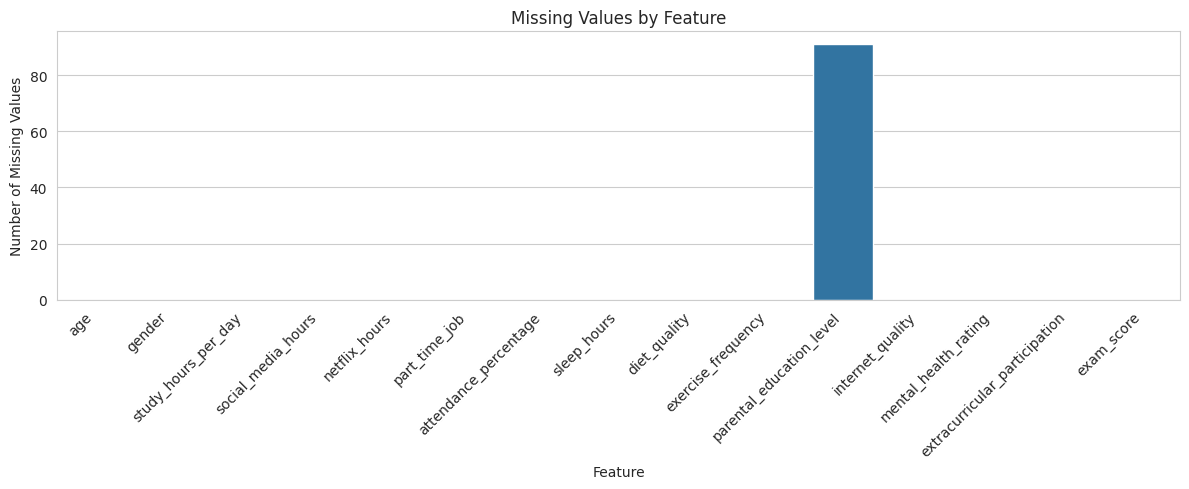

In [12]:
plt.figure(figsize=(12, 5))

sns.barplot(
    x=missing_df.index,
    y=missing_df["Missing Values"]
)

plt.xticks(rotation=45, ha="right")
plt.title("Missing Values by Feature")
plt.ylabel("Number of Missing Values")
plt.xlabel("Feature")
plt.tight_layout()
plt.show()

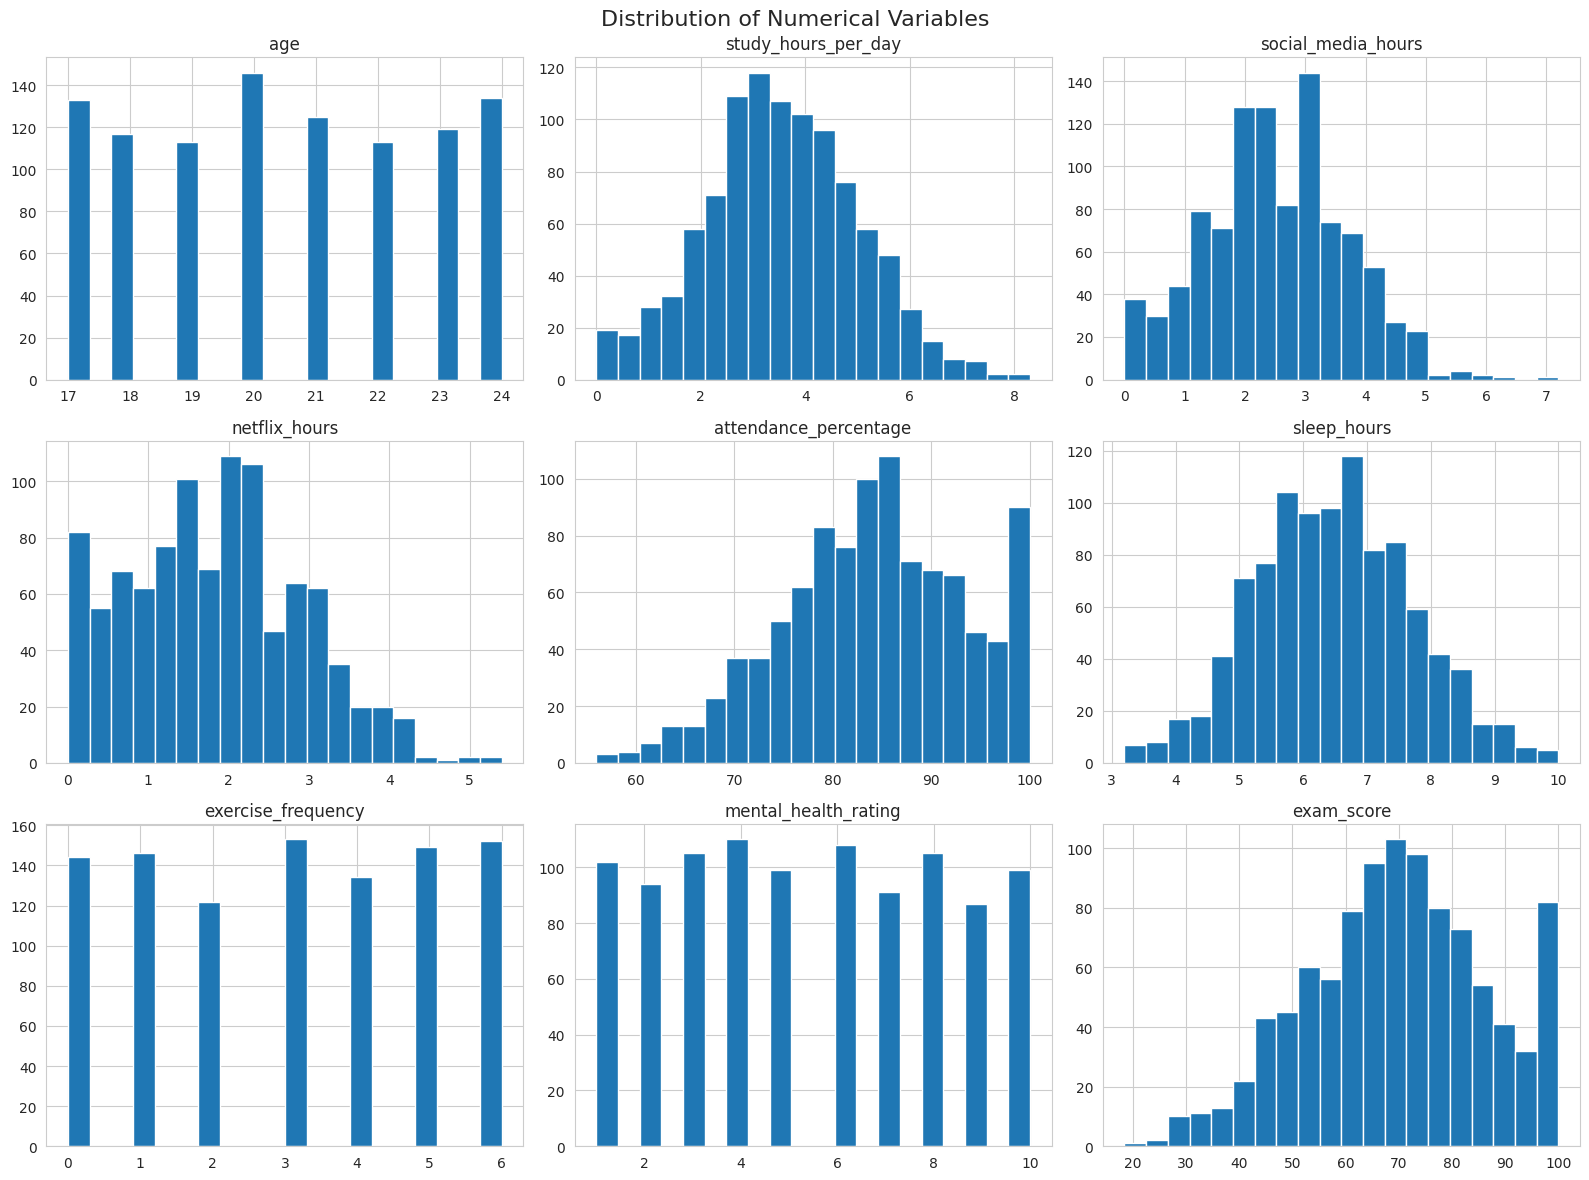

In [13]:
df.hist(
    figsize=(16, 12),
    bins=20
)

plt.suptitle(
    "Distribution of Numerical Variables",
    fontsize=16
)

plt.tight_layout()
plt.show()

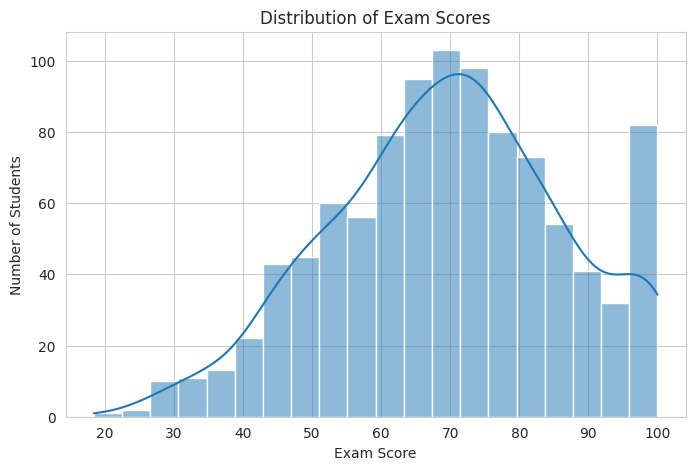

In [14]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["exam_score"],
    kde=True,
    bins=20
)

plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Number of Students")

plt.show()

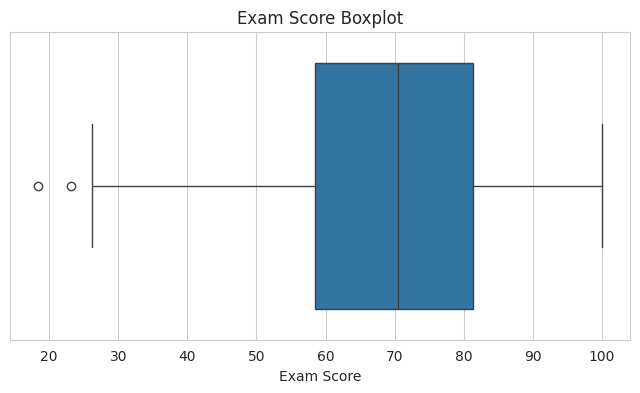

In [15]:
plt.figure(figsize=(8, 4))

sns.boxplot(
    x=df["exam_score"]
)

plt.title("Exam Score Boxplot")
plt.xlabel("Exam Score")

plt.show()

In [16]:
categorical_columns = df.select_dtypes(
    include="object"
).columns.tolist()

categorical_columns

['gender',
 'part_time_job',
 'diet_quality',
 'parental_education_level',
 'internet_quality',
 'extracurricular_participation']

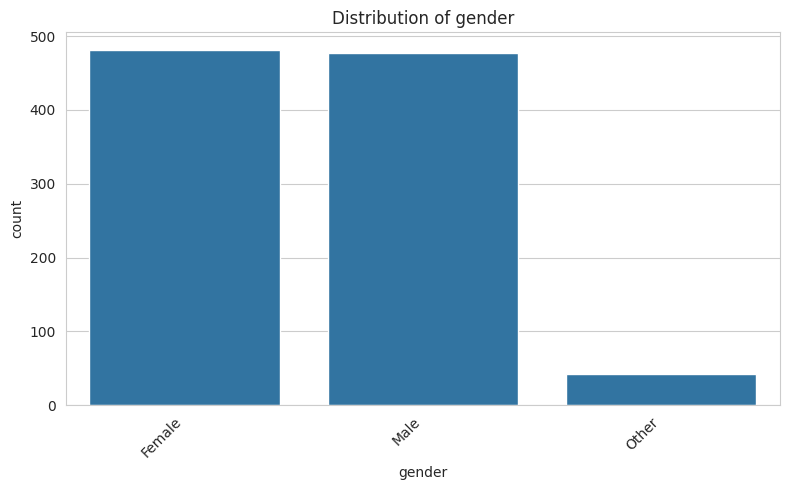

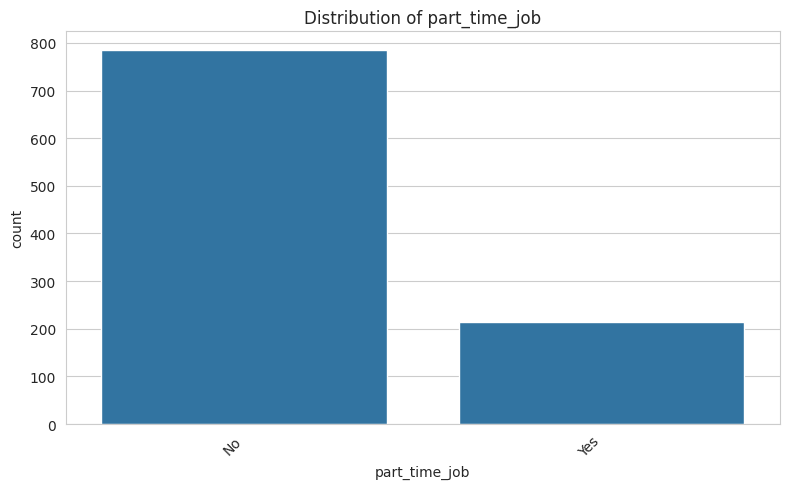

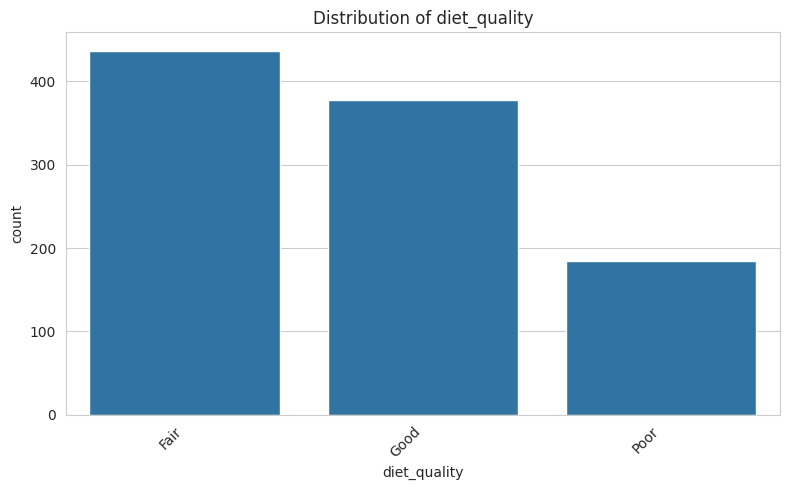

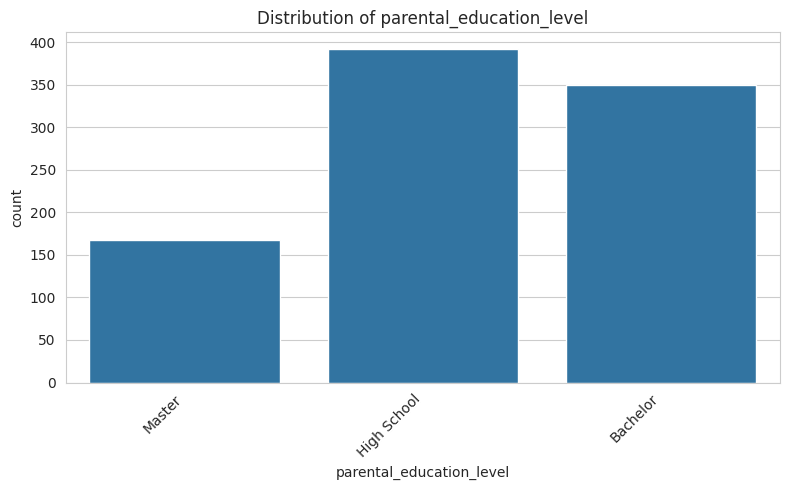

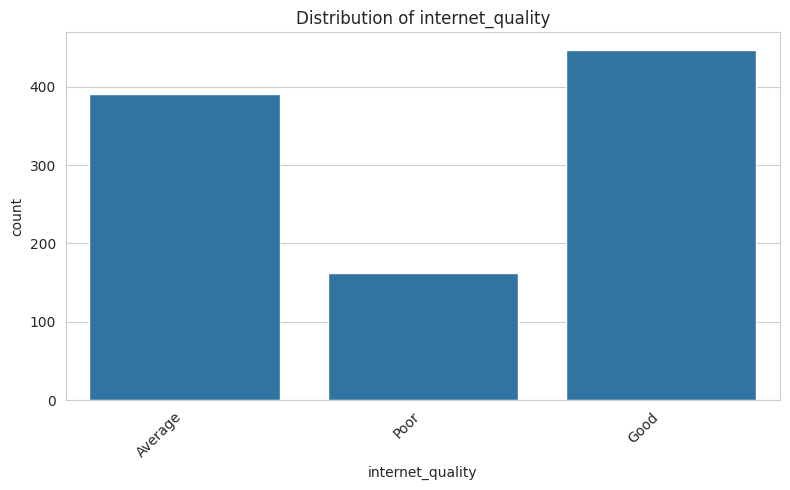

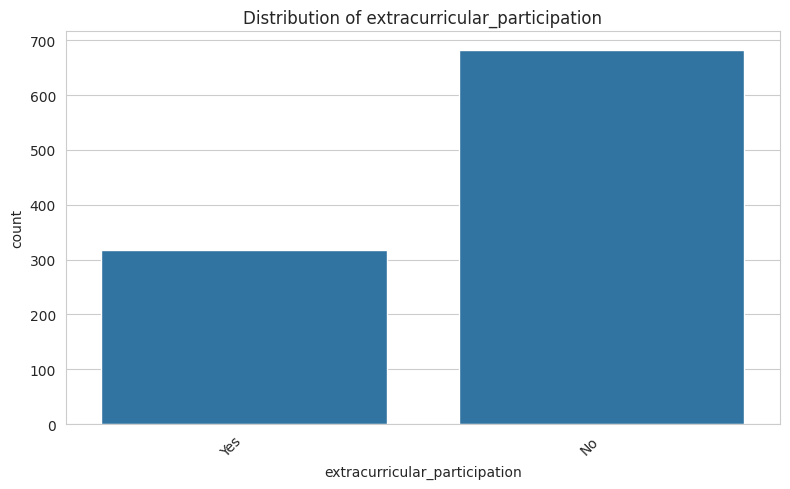

In [17]:
for column in categorical_columns:

    plt.figure(figsize=(8, 5))

    sns.countplot(
        data=df,
        x=column
    )

    plt.title(f"Distribution of {column}")
    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()
    plt.show()

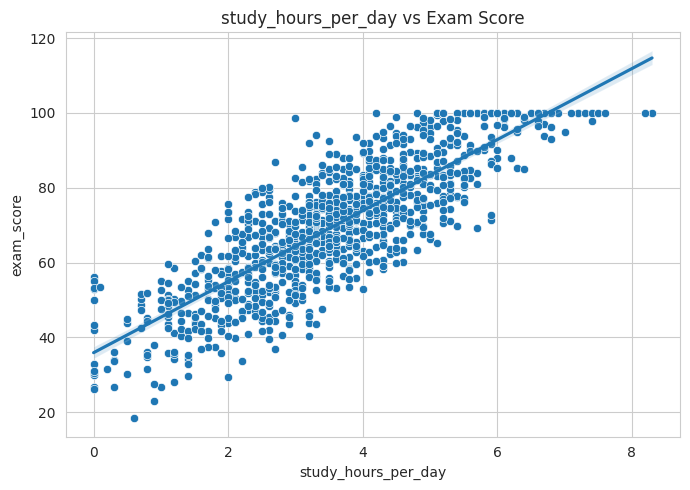

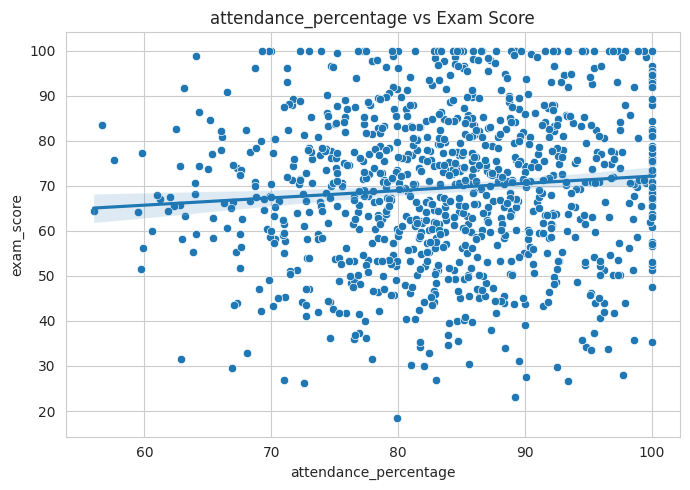

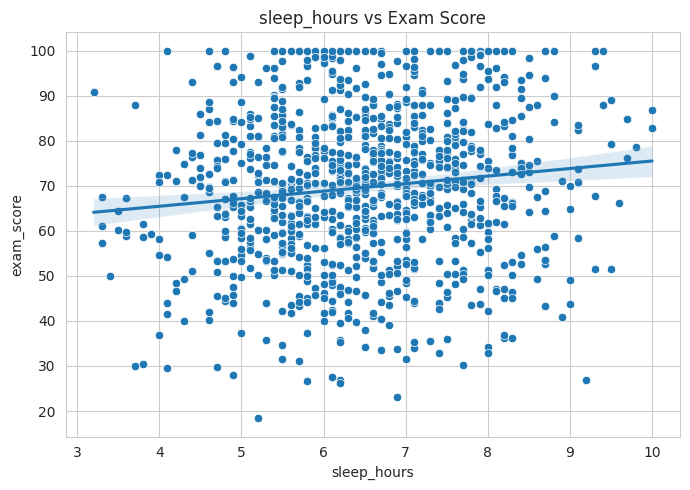

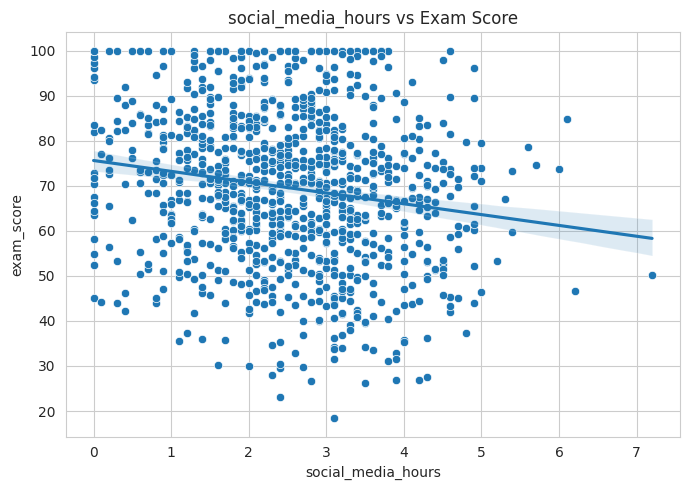

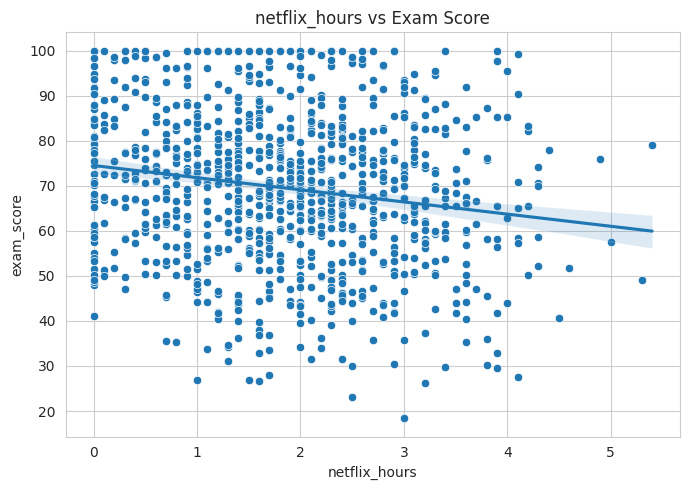

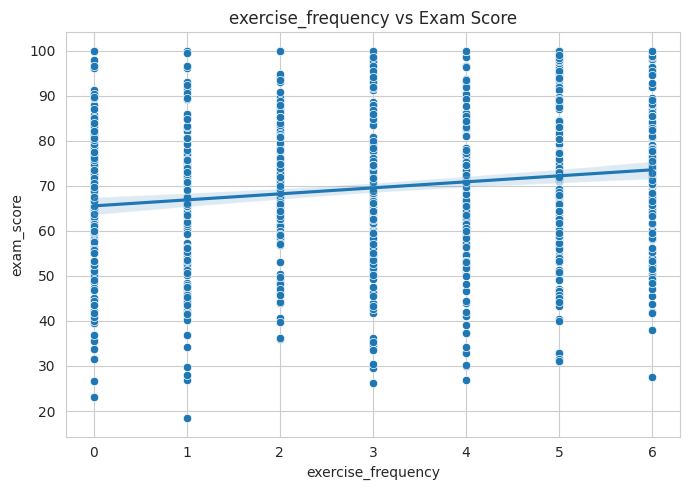

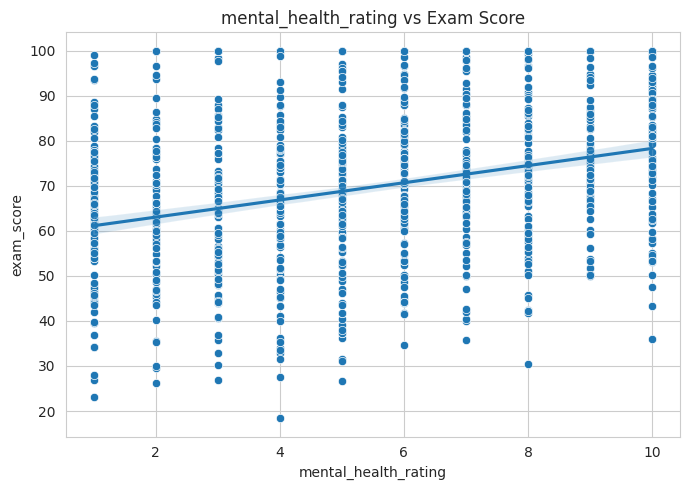

In [18]:
important_features = [
    "study_hours_per_day",
    "attendance_percentage",
    "sleep_hours",
    "social_media_hours",
    "netflix_hours",
    "exercise_frequency",
    "mental_health_rating"
]

for feature in important_features:

    if feature in df.columns:

        plt.figure(figsize=(7, 5))

        sns.scatterplot(
            data=df,
            x=feature,
            y="exam_score"
        )

        sns.regplot(
            data=df,
            x=feature,
            y="exam_score",
            scatter=False
        )

        plt.title(f"{feature} vs Exam Score")
        plt.tight_layout()
        plt.show()

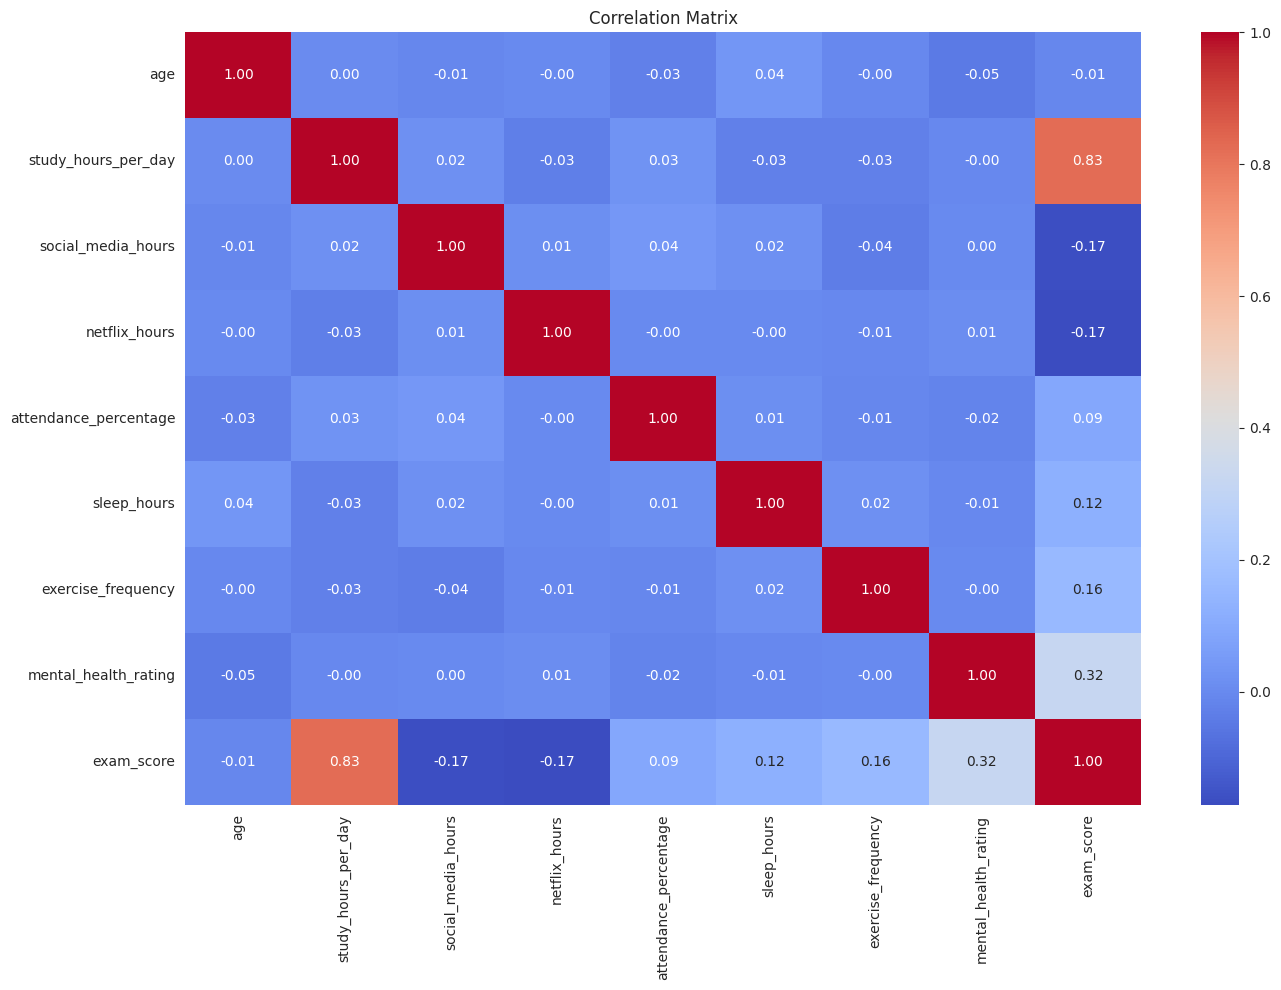

In [19]:
plt.figure(figsize=(14, 10))

correlation_matrix = df.select_dtypes(
    include=np.number
).corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

In [20]:
exam_correlations = (
    correlation_matrix["exam_score"]
    .sort_values(ascending=False)
)

print(exam_correlations)

exam_score               1.000000
study_hours_per_day      0.825419
mental_health_rating     0.321523
exercise_frequency       0.160107
sleep_hours              0.121683
attendance_percentage    0.089836
age                     -0.008907
social_media_hours      -0.166733
netflix_hours           -0.171779
Name: exam_score, dtype: float64


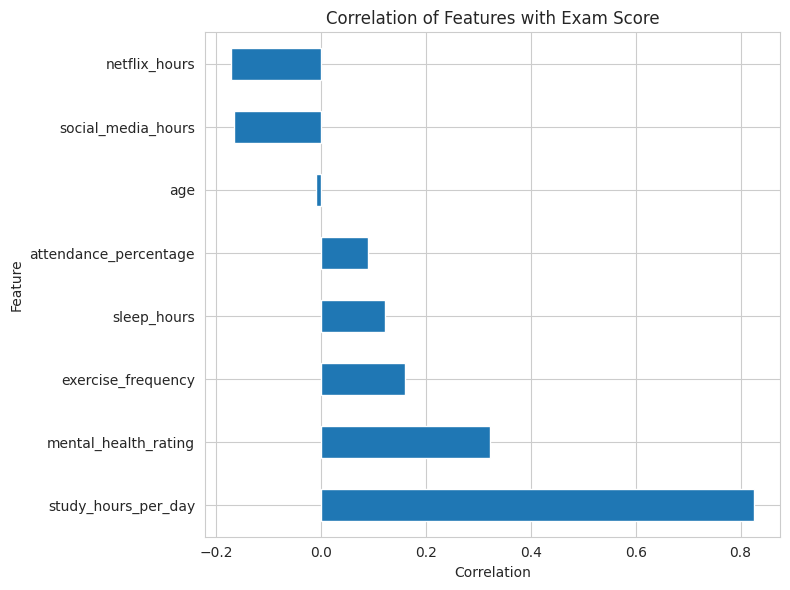

In [21]:
plt.figure(figsize=(8, 6))

exam_correlations.drop("exam_score").plot(
    kind="barh"
)

plt.title("Correlation of Features with Exam Score")
plt.xlabel("Correlation")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

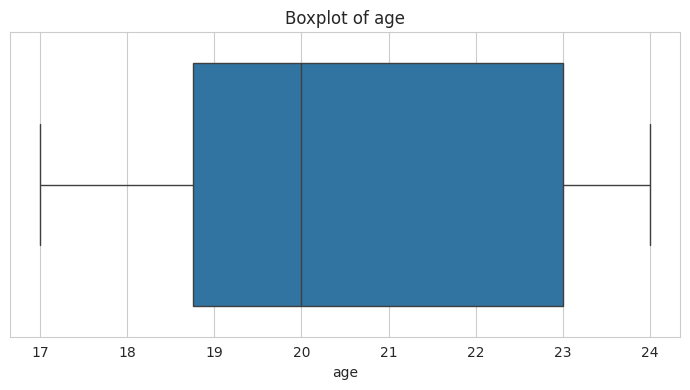

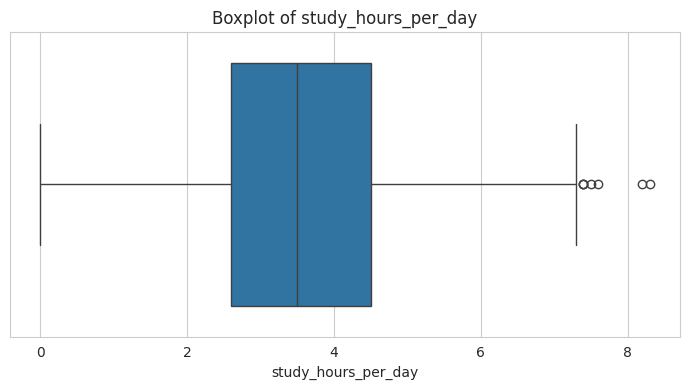

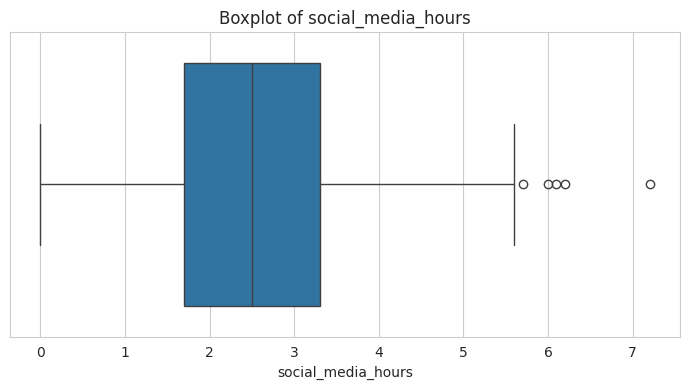

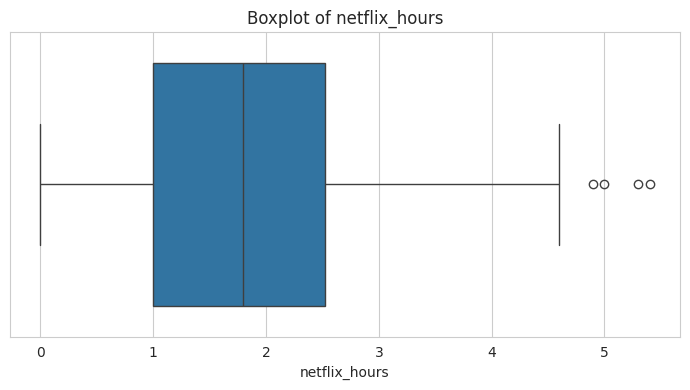

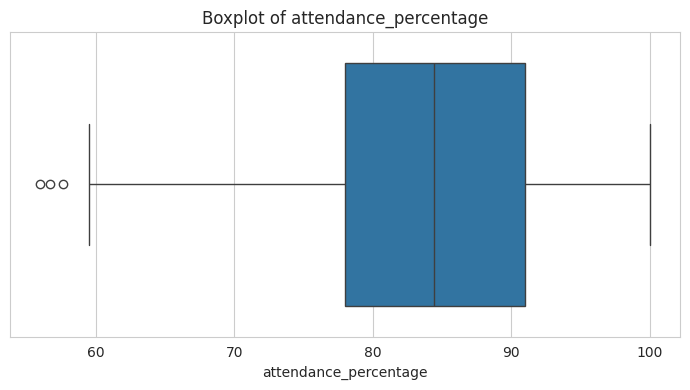

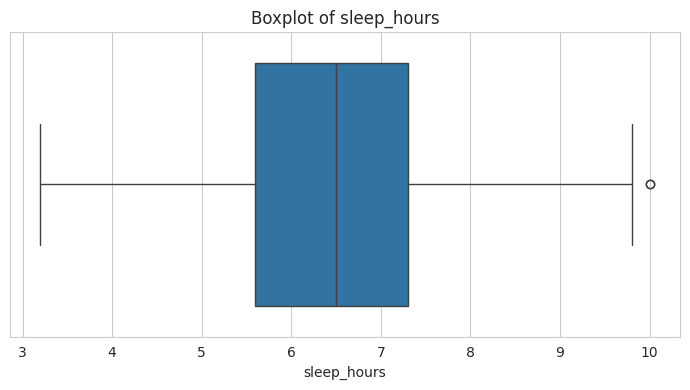

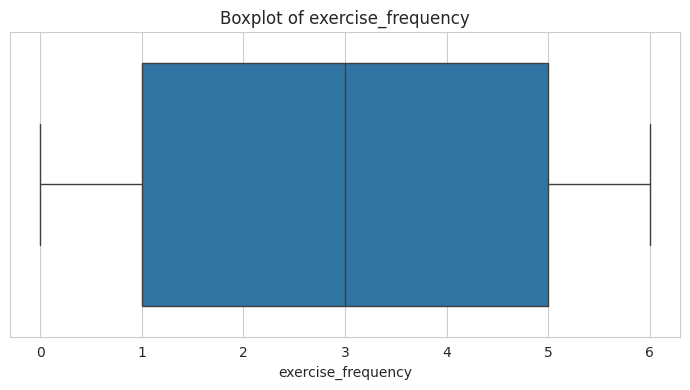

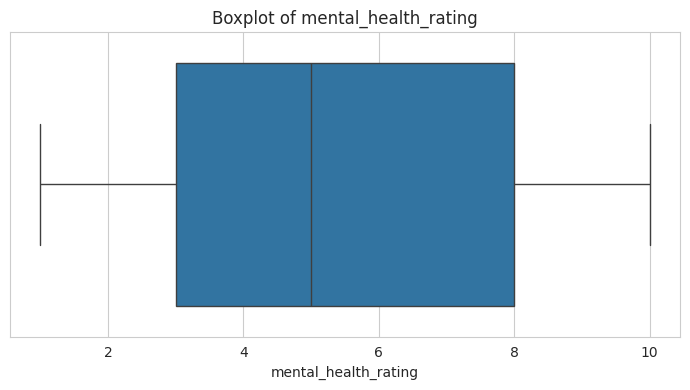

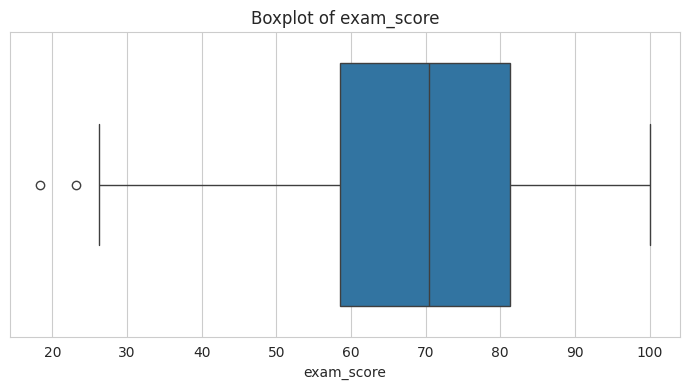

In [22]:
numerical_columns = df.select_dtypes(
    include=np.number
).columns.tolist()

for column in numerical_columns:

    plt.figure(figsize=(7, 4))

    sns.boxplot(
        x=df[column]
    )

    plt.title(f"Boxplot of {column}")

    plt.tight_layout()
    plt.show()

In [23]:
outlier_summary = {}

for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ]

    outlier_summary[column] = len(outliers)

outlier_summary

{'age': 0,
 'study_hours_per_day': 7,
 'social_media_hours': 5,
 'netflix_hours': 4,
 'attendance_percentage': 3,
 'sleep_hours': 2,
 'exercise_frequency': 0,
 'mental_health_rating': 0,
 'exam_score': 2}

In [24]:
features = [
    "age",
    "gender",
    "study_hours_per_day",
    "social_media_hours",
    "netflix_hours",
    "part_time_job",
    "attendance_percentage",
    "sleep_hours",
    "diet_quality",
    "exercise_frequency",
    "parental_education_level",
    "internet_quality",
    "mental_health_rating",
    "extracurricular_participation"
]

features = [
    feature for feature in features
    if feature in df.columns
]

print("Selected Features:")
print(features)

Selected Features:
['age', 'gender', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation']


In [25]:
X = df[features]
y = df["exam_score"]

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 800
Testing samples: 200


In [27]:
numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    include="object"
).columns.tolist()

print("Numerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating']

Categorical Features:
['gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']


In [28]:
numeric_transformer = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [29]:
regression_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

regression_model.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'study_hours_per_day',
                                                   'social_media_hours',
                                                   'netflix_hours',
                                                   'attendance_percentage',
                                                   'sleep_hours',
                                                   'exercise_frequency',
                                                   'mental_health_rating']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['gender', 'part_time_job',
                                                   'diet_quality',
                                                   'parental_education_level',
                                                   'internet_quality',
                                                   'extracurricular_participation'])])),
                ('model', LinearRegression())])

In [30]:
y_train_pred = regression_model.predict(X_train)
y_test_pred = regression_model.predict(X_test)

In [31]:
prediction_df = pd.DataFrame({
    "Actual Exam Score": y_test.values,
    "Predicted Exam Score": y_test_pred
})

prediction_df.head(10)

,Actual Exam Score,Predicted Exam Score
0,64.2,66.277099
1,72.7,75.205244
2,79.0,77.767816
3,79.5,73.427429
4,58.2,61.071545
5,53.4,54.040092
6,70.8,75.564305
7,62.5,55.095949
8,36.8,40.752727
9,67.6,72.405539


In [32]:
train_mae = mean_absolute_error(
    y_train,
    y_train_pred
)

test_mae = mean_absolute_error(
    y_test,
    y_test_pred
)

train_mse = mean_squared_error(
    y_train,
    y_train_pred
)

test_mse = mean_squared_error(
    y_test,
    y_test_pred
)

train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)

train_r2 = r2_score(
    y_train,
    y_train_pred
)

test_r2 = r2_score(
    y_test,
    y_test_pred
)

In [33]:
regression_results = pd.DataFrame({
    "Metric": [
        "MAE",
        "MSE",
        "RMSE",
        "R² Score"
    ],
    "Training": [
        train_mae,
        train_mse,
        train_rmse,
        train_r2
    ],
    "Testing": [
        test_mae,
        test_mse,
        test_rmse,
        test_r2
    ]
})

regression_results

,Metric,Training,Testing
0,MAE,4.212312,4.189311
1,MSE,28.554912,26.476236
2,RMSE,5.343680,5.145506
3,R² Score,0.902146,0.896750


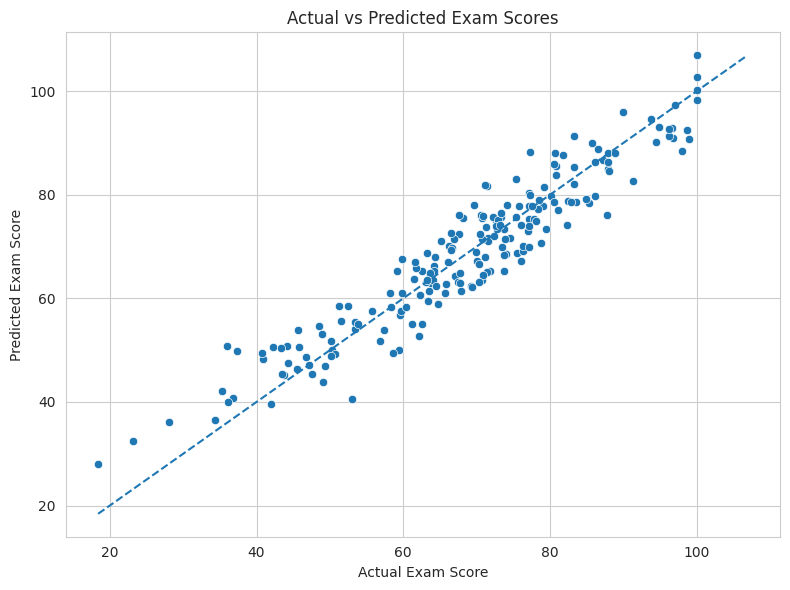

In [34]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=y_test_pred
)

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Scores")

min_value = min(
    y_test.min(),
    y_test_pred.min()
)

max_value = max(
    y_test.max(),
    y_test_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.tight_layout()
plt.show()

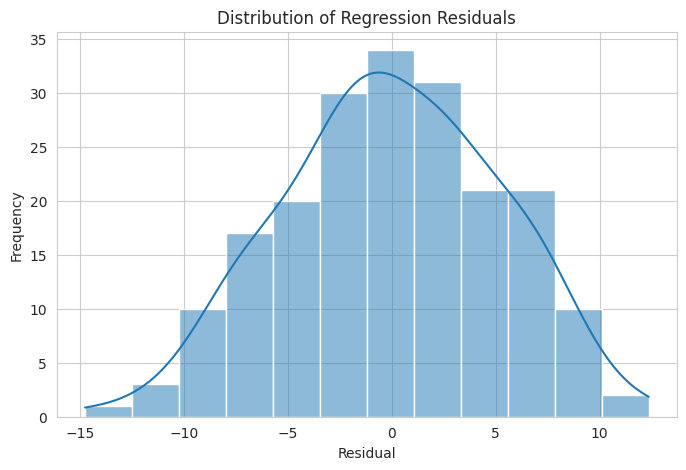

In [35]:
residuals = y_test - y_test_pred

plt.figure(figsize=(8, 5))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Distribution of Regression Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.show()

In [36]:
df["pass_fail"] = np.where(
    df["exam_score"] >= 50,
    1,
    0
)

df["pass_fail"].value_counts()

,count
pass_fail,
1,869
0,131


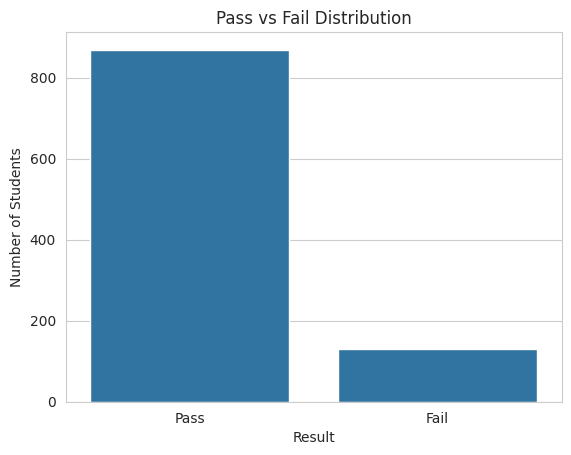

In [37]:
df["pass_fail_label"] = df["pass_fail"].map({
    0: "Fail",
    1: "Pass"
})

sns.countplot(
    data=df,
    x="pass_fail_label"
)

plt.title("Pass vs Fail Distribution")
plt.xlabel("Result")
plt.ylabel("Number of Students")

plt.show()

In [38]:
X_classification = df[features]
y_classification = df["pass_fail"]

In [39]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_classification,
    y_classification,
    test_size=0.20,
    random_state=42,
    stratify=y_classification
)

In [40]:
numeric_features_cls = X_classification.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features_cls = X_classification.select_dtypes(
    include="object"
).columns.tolist()

preprocessor_cls = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features_cls
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features_cls
        )
    ]
)

In [41]:
classification_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_cls
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000
            )
        )
    ]
)

classification_model.fit(
    X_train_cls,
    y_train_cls
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'study_hours_per_day',
                                                   'social_media_hours',
                                                   'netflix_hours',
                                                   'attendance_percentage',
                                                   'sleep_hours',
                                                   'exercise_frequency',
                                                   'mental_health_rating']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'part_time_job',
                                                   'diet_quality',
                                                   'parental_education_level',
                                                   'internet_quality',
                                                   'extracurricular_participation'])])),
                ('model', LogisticRegression(max_iter=1000))])

In [42]:
y_train_cls_pred = classification_model.predict(
    X_train_cls
)

y_test_cls_pred = classification_model.predict(
    X_test_cls
)

In [43]:
accuracy = accuracy_score(
    y_test_cls,
    y_test_cls_pred
)

precision = precision_score(
    y_test_cls,
    y_test_cls_pred,
    zero_division=0
)

recall = recall_score(
    y_test_cls,
    y_test_cls_pred,
    zero_division=0
)

f1 = f1_score(
    y_test_cls,
    y_test_cls_pred,
    zero_division=0
)

classification_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

classification_results

,Metric,Score
0,Accuracy,0.955000
1,Precision,0.971429
2,Recall,0.977011
3,F1-Score,0.974212


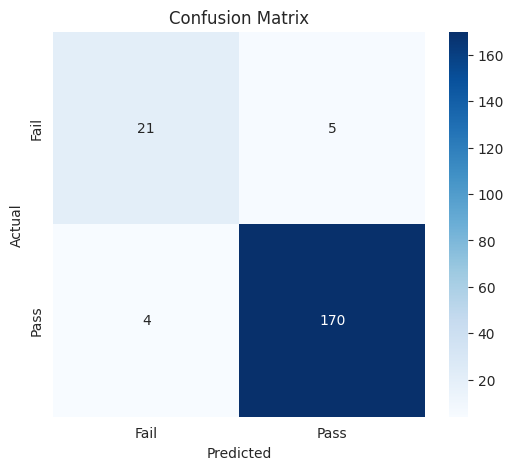

In [44]:
cm = confusion_matrix(
    y_test_cls,
    y_test_cls_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fail", "Pass"],
    yticklabels=["Fail", "Pass"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [45]:
print(
    classification_report(
        y_test_cls,
        y_test_cls_pred,
        target_names=["Fail", "Pass"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

        Fail       0.84      0.81      0.82        26
        Pass       0.97      0.98      0.97       174

    accuracy                           0.95       200
   macro avg       0.91      0.89      0.90       200
weighted avg       0.95      0.95      0.95       200



In [46]:
train_accuracy = accuracy_score(
    y_train_cls,
    y_train_cls_pred
)

test_accuracy = accuracy_score(
    y_test_cls,
    y_test_cls_pred
)

train_precision = precision_score(
    y_train_cls,
    y_train_cls_pred,
    zero_division=0
)

test_precision = precision_score(
    y_test_cls,
    y_test_cls_pred,
    zero_division=0
)

train_recall = recall_score(
    y_train_cls,
    y_train_cls_pred,
    zero_division=0
)

test_recall = recall_score(
    y_test_cls,
    y_test_cls_pred,
    zero_division=0
)

train_f1 = f1_score(
    y_train_cls,
    y_train_cls_pred,
    zero_division=0
)

test_f1 = f1_score(
    y_test_cls,
    y_test_cls_pred,
    zero_division=0
)

In [47]:
classification_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Training": [
        train_accuracy,
        train_precision,
        train_recall,
        train_f1
    ],
    "Testing": [
        test_accuracy,
        test_precision,
        test_recall,
        test_f1
    ]
})

classification_comparison

,Metric,Training,Testing
0,Accuracy,0.958750,0.955000
1,Precision,0.970170,0.971429
2,Recall,0.982734,0.977011
3,F1-Score,0.976412,0.974212


In [48]:
print("Regression Performance")
print("----------------------")
print(f"Training R² : {train_r2:.4f}")
print(f"Testing R²  : {test_r2:.4f}")
print(f"Training RMSE: {train_rmse:.4f}")
print(f"Testing RMSE : {test_rmse:.4f}")

Regression Performance
----------------------
Training R² : 0.9021
Testing R²  : 0.8968
Training RMSE: 5.3437
Testing RMSE : 5.1455


In [49]:
print("Classification Performance")
print("--------------------------")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy : {test_accuracy:.4f}")
print(f"Training F1      : {train_f1:.4f}")
print(f"Testing F1       : {test_f1:.4f}")

Classification Performance
--------------------------
Training Accuracy: 0.9587
Testing Accuracy : 0.9550
Training F1      : 0.9764
Testing F1       : 0.9742


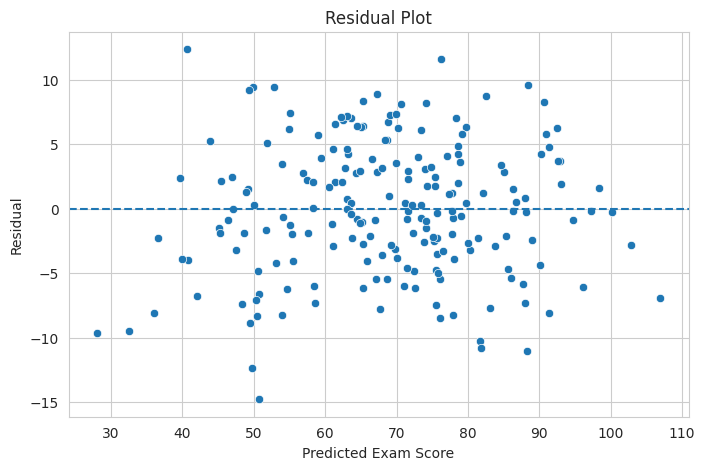

In [50]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=y_test_pred,
    y=residuals
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Predicted Exam Score")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.show()

In [51]:
correlation_without_target = (
    exam_correlations
    .drop("exam_score")
)

strongest_positive = (
    correlation_without_target
    .sort_values(ascending=False)
    .head(5)
)

strongest_negative = (
    correlation_without_target
    .sort_values()
    .head(5)
)

print("Strongest Positive Relationships:")
print(strongest_positive)

print("\nStrongest Negative Relationships:")
print(strongest_negative)

Strongest Positive Relationships:
study_hours_per_day      0.825419
mental_health_rating     0.321523
exercise_frequency       0.160107
sleep_hours              0.121683
attendance_percentage    0.089836
Name: exam_score, dtype: float64

Strongest Negative Relationships:
netflix_hours           -0.171779
social_media_hours      -0.166733
age                     -0.008907
attendance_percentage    0.089836
sleep_hours              0.121683
Name: exam_score, dtype: float64
